/tmp/ipykernel_636/1617913037.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content")


Dataset downloaded successfully!
Total dog images: 4990
Number of dog breeds: 25
Training images: 3992
Testing images: 998
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,177 (9.25 MB)

 Trainable params: 167,193 (653.10 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 86s 790ms/step - accuracy: 0.7520 - loss: 0.8892 - val_accuracy: 0.8598 - val_loss: 0.4336
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 79s 769ms/step - accuracy: 0.9223 - loss: 0.2519 - val_accuracy: 0.8761 - val_loss: 0.3767
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 776ms/step - accuracy: 0.9681 - loss: 0.1190 - val_accuracy: 0.8811 - val_loss: 0.3545

Fine-tuning model...
Epoch 1/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.9277 - loss: 0.2298 - val_accuracy: 0.8811 - val_loss: 0.3862
Epoch 2/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.9850 - loss: 0.0723 - val_accuracy: 0.9024 - val_loss: 0.3334

Test Accuracy: 88.88 %
Test Loss: 0.382


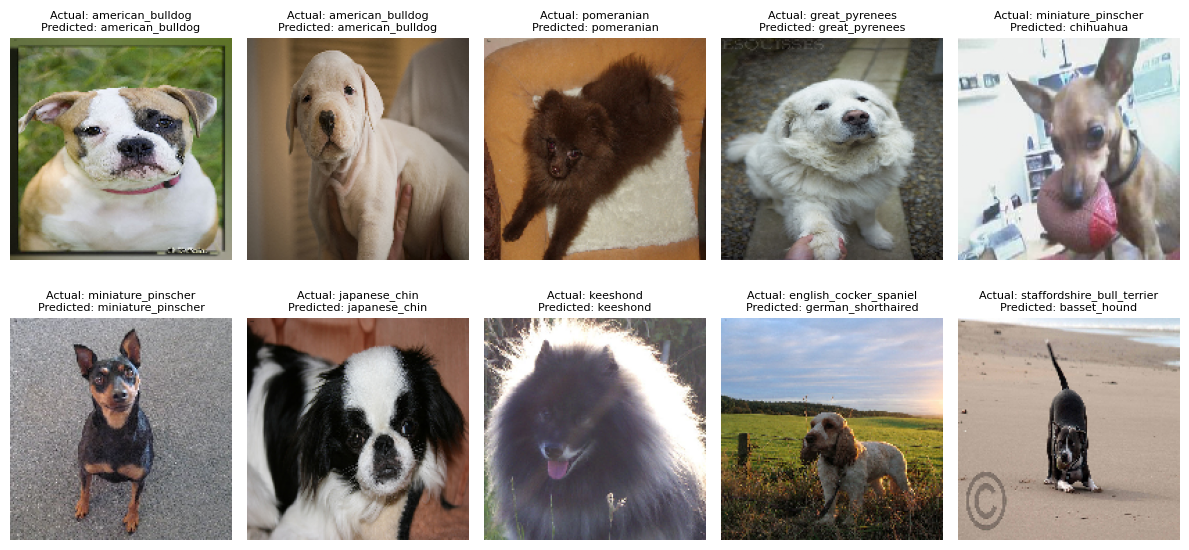

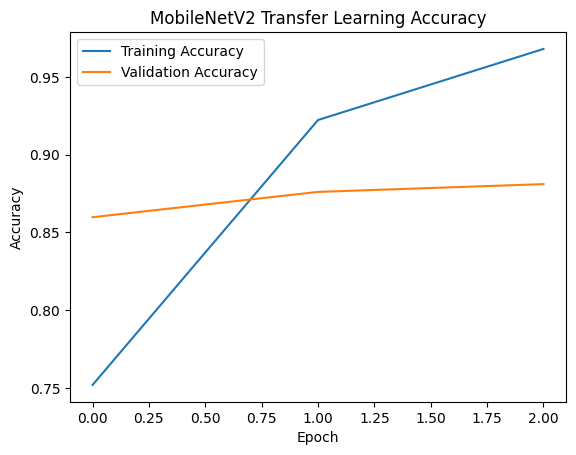

In [2]:
# SHLOK VIJ
# PRN: 23070521143

import os
import tarfile
import urllib.request
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Sequential

# Download Oxford-IIIT Pet images
url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
file_path = "/content/images.tar.gz"

urllib.request.urlretrieve(url, file_path)

# Extract images
with tarfile.open(file_path, "r:gz") as tar:
    tar.extractall("/content")

print("Dataset downloaded successfully!")

# 25 dog breeds
dog_breeds = [
    "american_bulldog",
    "american_pit_bull_terrier",
    "basset_hound",
    "beagle",
    "boxer",
    "chihuahua",
    "english_cocker_spaniel",
    "english_setter",
    "german_shorthaired",
    "great_pyrenees",
    "havanese",
    "japanese_chin",
    "keeshond",
    "leonberger",
    "miniature_pinscher",
    "newfoundland",
    "pomeranian",
    "pug",
    "saint_bernard",
    "samoyed",
    "scottish_terrier",
    "shiba_inu",
    "staffordshire_bull_terrier",
    "wheaten_terrier",
    "yorkshire_terrier"
]

breed_to_label = {
    breed: i for i, breed in enumerate(dog_breeds)
}

# Load images
image_folder = "/content/images"

X = []
y = []

for filename in os.listdir(image_folder):

    if not filename.endswith(".jpg"):
        continue

    name = filename[:-4]

    # Remove image number
    breed = "_".join(name.split("_")[:-1]).lower()

    if breed in breed_to_label:

        image = tf.keras.utils.load_img(
            os.path.join(image_folder, filename),
            target_size=(160, 160)
        )

        image = tf.keras.utils.img_to_array(image)

        X.append(image)
        y.append(breed_to_label[breed])

X = np.array(X, dtype="float32")
y = np.array(y)

print("Total dog images:", len(X))
print("Number of dog breeds:", len(dog_breeds))

# Normalize images
X = X / 255.0

# Shuffle data
indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]

# Train-test split
split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]

print("Training images:", len(X_train))
print("Testing images:", len(X_test))

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(160, 160, 3)
)

# Freeze pretrained layers
base_model.trainable = False

# Create model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dense(25, activation="softmax")
])

# Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Model summary
model.summary()

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.2
)

# Fine-tuning
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nFine-tuning model...")

model.fit(
    X_train,
    y_train,
    epochs=2,
    batch_size=32,
    validation_split=0.2
)

# Evaluate model
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nTest Accuracy:", round(accuracy * 100, 2), "%")
print("Test Loss:", round(loss, 4))

# Predictions
predictions = model.predict(
    X_test[:10],
    verbose=0
)

predicted_labels = np.argmax(
    predictions,
    axis=1
)

# Display predictions
plt.figure(figsize=(12, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[i])

    actual = dog_breeds[y_test[i]]
    predicted = dog_breeds[predicted_labels[i]]

    plt.title(
        "Actual: " + actual +
        "\nPredicted: " + predicted,
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Accuracy graph
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Transfer Learning Accuracy")
plt.legend()
plt.show()